In [1]:
pip install torch torchvision pandas scikit-learn pillow kagglehub

Using Colab cache for faster access to the 'annotated-facial-images-for-stroke-classification' dataset.
✅ SUCCESS: Valid dataset found at: /kaggle/input/annotated-facial-images-for-stroke-classification/Annotated stroke and non stroke Dataset
Classes Detected: ['NonStroke', 'Stroke']
Training Images: 2999 | Validation Images: 750
Training on: cpu

Starting Training...
Epoch 1/10 | Train Acc: 64.6% | Val Acc: 66.3% | Val Loss: 0.5614
Epoch 2/10 | Train Acc: 74.1% | Val Acc: 84.9% | Val Loss: 0.3955
Epoch 3/10 | Train Acc: 83.9% | Val Acc: 88.3% | Val Loss: 0.3212
Epoch 4/10 | Train Acc: 88.3% | Val Acc: 91.5% | Val Loss: 0.2644
Epoch 5/10 | Train Acc: 89.2% | Val Acc: 91.6% | Val Loss: 0.2368
Epoch 6/10 | Train Acc: 92.1% | Val Acc: 94.4% | Val Loss: 0.1657
Epoch 7/10 | Train Acc: 94.2% | Val Acc: 92.9% | Val Loss: 0.1672
Epoch 8/10 | Train Acc: 96.2% | Val Acc: 95.7% | Val Loss: 0.1089
Epoch 9/10 | Train Acc: 98.0% | Val Acc: 98.3% | Val Loss: 0.0509
Epoch 10/10 | Train Acc: 96.4% | Va

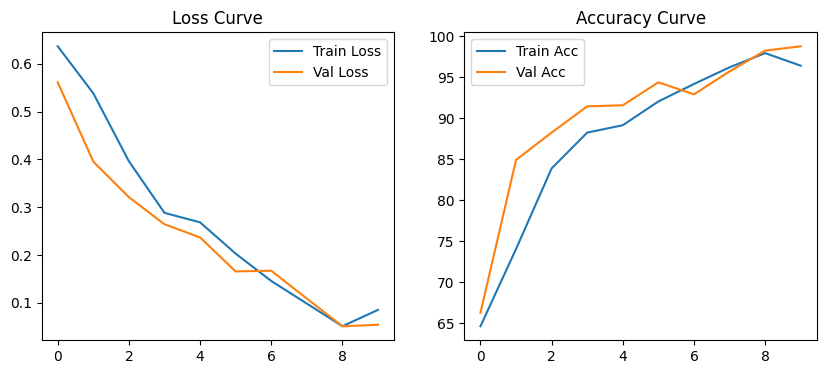

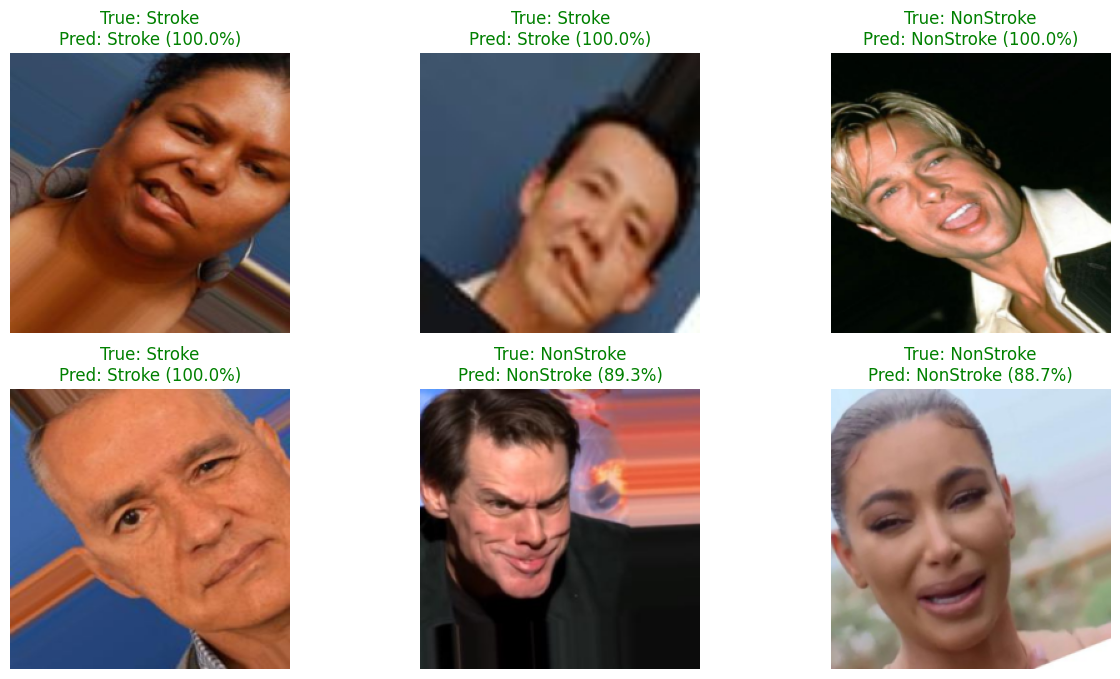

Model saved successfully.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import kagglehub
import os
import numpy as np

# ==========================================
# 1. DOWNLOAD & SMART PATH FINDING
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("abdussalamelhanashy/annotated-facial-images-for-stroke-classification")

def find_valid_data_root(start_path):
    """
    Walks through the directory tree to find the folder
    that actually contains 'Stroke' and 'NonStroke' subfolders.
    """
    for root, dirs, files in os.walk(start_path):
        # We look for the specific class folder names from your screenshot
        if "Stroke" in dirs and "NonStroke" in dirs:
            return root
    return None

# Find the correct folder automatically
dataset_root = find_valid_data_root(path)

if dataset_root is None:
    raise ValueError(f"CRITICAL ERROR: Could not find 'Stroke' and 'NonStroke' folders inside {path}. Check the download.")
else:
    print(f"✅ SUCCESS: Valid dataset found at: {dataset_root}")

# ==========================================
# 2. IMAGE PREPROCESSING
# ==========================================
# [cite_start]Source 1 [cite: 154-155] requires resizing to 224x224
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), # Converts 0-255 to 0.0-1.0
])

# ==========================================
# 3. LOAD DATA
# ==========================================
full_dataset = datasets.ImageFolder(dataset_root, transform=data_transforms)
class_names = full_dataset.classes

# SAFETY CHECK: If this prints only 1 class, we stop immediately.
print(f"Classes Detected: {class_names}")
if len(class_names) < 2:
    raise RuntimeError("❌ ERROR: Only 1 class detected. The path is still wrong.")

# [cite_start]Split 80% Train, 20% Validation [cite: 173-174]
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Training Images: {len(train_data)} | Validation Images: {len(val_data)}")

# ==========================================
# 4. DEFINE MODEL (Source 1 Architecture)
# ==========================================
# [cite_start]4-Layer Custom CNN [cite: 157-164]
class SimpleStrokeCNN(nn.Module):
    def __init__(self):
        super(SimpleStrokeCNN, self).__init__()

        # 16 -> 32 -> 64 -> 128 Filters
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # Dense: 128 filters * 14 * 14 pixels
        self.fc1 = nn.Linear(128 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 2) # Output: 2 Classes

    def forward(self, x):
        x = self.dropout(self.pool(F.relu(self.conv1(x))))
        x = self.dropout(self.pool(F.relu(self.conv2(x))))
        x = self.dropout(self.pool(F.relu(self.conv3(x))))
        x = self.dropout(self.pool(F.relu(self.conv4(x))))

        x = x.view(-1, 128 * 14 * 14)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ==========================================
# 5. TRAIN MODEL
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = SimpleStrokeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nStarting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate Metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(epoch_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(epoch_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_acc:.1f}% | Val Acc: {val_acc:.1f}% | Val Loss: {avg_val_loss:.4f}")

# ==========================================
# 6. VISUALIZE RESULTS
# ==========================================
# A. Loss Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# B. Prediction Grid (To verify labels)
def visualize_model(model, loader):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    preds = preds.cpu()
    labels = labels.cpu()
    probs = probs.cpu()

    plt.figure(figsize=(15, 8))
    for i in range(min(6, len(images))):
        ax = plt.subplot(2, 3, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        plt.imshow(img)

        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]
        conf = probs[i][preds[i]].item() * 100

        color = 'green' if preds[i] == labels[i] else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)", color=color)
        plt.axis('off')
    plt.show()

visualize_model(model, val_loader)

# Save
torch.save(model.state_dict(), "stroke_mvp_model.pth")
print("Model saved successfully.")
